# Analise Epidemiológica de Dengue dos anos de 2024 e 2025

_**Elaborado por:**_ `Vitor Emanuel Santos Cruz` (vitoremanuelsc089@gmail.com)

_**Data:**_ `16/04/2025`

###**Introdução**
Este notebook apresenta uma Análise focada na epidemiologia da Dengue. O estudo investiga os registros dos anos de 2024 e 2025, partindo de uma filtragem macro do estado de Minas Gerais para criar um recorte analítico específico do município de Montes Claros.

### 1. Contextualização
A dengue é um dos grandes desafios de saúde pública no Brasil, apresentando um padrão sazonal cíclico, mas com picos epidêmicos que colocam em risco a capacidade de resposta das redes de saúde municipais. Assim, o foco do trabalho seria entender se padrões podem ser identificados.

### 2. Metodologias
* **Coleta de Dados:** Utilização da biblioteca `PySUS` para acesso direto aos dados do SINAN (Sistema de Informação de Agravos de Notificação).
* **Tratamento de Dados:** Analise critica a respeito da satisfação dos dados, incluindo normalização e limpeza.
* **Analise Exploratoria de Dados:** Utilização de abordagens estatísticas e visuais para compreender e resumir conjuntos de dados.

### 3. Perguntas Propostas
1. **Sazonalidade:** Como se comportou a curva de infecção de Dengue nos anos de 2024 e 2025 anos em Montes Claros?
2. **Perfil Demográfico:** Qual é a faixa etária e o sexo predominante entre os casos notificados em Montes Claros?
3. **Perfil Demográfico:** Existe alguma diferença no tempo de primeiro sintoma até data da consulta entre os marcadores de sexo?  
4. **Indicadores de Gravidade:** Houve um aumento proporcional de casos graves durante a epidemia ou apenas um aumento no volume total de notificações?

---
## Preparação do Ambiente e Extração de Dados

In [ ]:
#import de bibliotecas necessarias + import de drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Código utilizado para puxar os dados de dengue em 2024 e 2025


```
from pysus.online_data import SINAN
import glob


SINAN.download('DENG', 2024)
SINAN.download('DENG', 2025)

arquivos_parquet = glob.glob('/root/pysus/*.parquet')

if arquivos_parquet:
    caminho_2024 = arquivos_parquet[0]
    caminho_2025 = arquivos_parquet[1]

    colunas = ['TP_NOT', 'DT_NOTIFIC', 'DT_SIN_PRI', 'CS_SEXO', 'NU_IDADE_N', 'CLASSI_FIN', 'EVOLUCAO', 'SG_UF_NOT', 'ID_MUNICIP']

    df_2024 = pd.read_parquet(
        caminho_2024,
        columns=colunas,
        filters=[('SG_UF_NOT', '==', '31')]
    )
    df_2025 = pd.read_parquet(
        caminho_2025,
        columns = colunas,
        filters = [('SG_UF_NOT', '==', '31')]
    )

    df = pd.concat([df_2024, df_2025], ignore_index = True)
else:
    print("Erro: Não encontrei a pasta do arquivo.")
```



In [ ]:
#importa o dataset em parquet
#import gdown

file_id = '12cfxAv8U0xIfzwr5ns1oHUBObr2nhxdz' #dados extraidos do pysus foram colocados no drive, e estaram sendo usados a partir de lá
url = f'https://drive.google.com/uc?id={file_id}'

output = 'dados_dengue_minas.parquet'
#gdown.download(url, output, quiet=True)

df = pd.read_parquet(output) #define df
print(f"Total de Minas: {len(df)}")

ModuleNotFoundError: No module named 'gdown'

##Tratamento e Limpeza dos Dados

In [ ]:
df.head()

,TP_NOT,DT_NOTIFIC,DT_SIN_PRI,CS_SEXO,NU_IDADE_N,CLASSI_FIN,EVOLUCAO,SG_UF_NOT,ID_MUNICIP
0,2,20250503,20250501,M,4027,10,1,31,310070
1,2,20251221,20251220,M,4014,10,1,31,316470
2,2,20250205,20250202,M,4053,10,1,31,313360
3,2,20250313,20250313,M,4029,10,1,31,312710
4,2,20250316,20250313,F,4059,10,1,31,313868


In [ ]:
df.shape

(1821299, 9)

In [ ]:
df.describe()

,TP_NOT,DT_NOTIFIC,DT_SIN_PRI,CS_SEXO,NU_IDADE_N,CLASSI_FIN,EVOLUCAO,SG_UF_NOT,ID_MUNICIP
count,1821299,1821299,1821299,1821299,1821299,1821299,1821299,1821299,1821299
unique,2,799,735,4,312,5,6,1,853
top,2,20240311,20240318,F,4024,10,1,31,310620
freq,1821296,27959,21921,1005878,36210,1511499,1418307,1821299,255646


In [ ]:
# pd.to_datetime converte o texto em formato de data oficial.
# errors='coerce' faz com que datas corrompidas fiquem vazias (NaT).
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], errors='coerce')

def corrigir_idade(codigo):
    if pd.isna(codigo):
        return np.nan #indica vazio

    cod_str = str(int(codigo))

    if len(cod_str) != 4:
        return np.nan

    unidade = cod_str[0]
    valor = int(cod_str[1:])

    if unidade == '4':
        return valor # anos
    elif unidade in ['2', '3']:
        return 0 # Meses e dias são arredondados para 0 anos
    else:
        return np.nan

df['NU_IDADE_N'] = df['NU_IDADE_N'].apply(corrigir_idade)

In [ ]:
# exclui apenas as linhas onde a coluna da idade esta vazia
df = df.dropna(subset=['NU_IDADE_N'])

In [ ]:
print(f"Total de casos em MG: {len(df)}")

# desconsidera idades que provavelmente foram digitadas erradas
df = df[df['NU_IDADE_N'] <= 130]

print(f"Total após apagar o outlier absurdo: {len(df)}\n")

Total de casos em MG: 1821215
Total após apagar o outlier absurdo: 1821165



In [ ]:
# filtro para montes claros
# código IBGE de Montes Claros: 314330
df_moc = df[df['ID_MUNICIP'] == '314330'].copy()

In [ ]:
df_moc.shape

(17928, 9)

In [ ]:
# limpa espaços invisiveis
df_moc['CLASSI_FIN'] = df_moc['CLASSI_FIN'].astype(str).str.strip()

# implementa dicionario para diagnostico (melhora o tratamento de dados)
dicionario_dengue = {
    '10': 'Dengue Clássica', '10.0': 'Dengue Clássica',
    '11': 'Dengue com Alarme', '11.0': 'Dengue com Alarme',
    '12': 'Dengue Grave', '12.0': 'Dengue Grave',
    '5': 'Descartado', '5.0': 'Descartado',
    '8': 'Inconclusivo', '8.0': 'Inconclusivo'
}

df_moc['DIAGNOSTICO'] = df_moc['CLASSI_FIN'].map(dicionario_dengue)

---
##Análise

###**Sazonalidade**

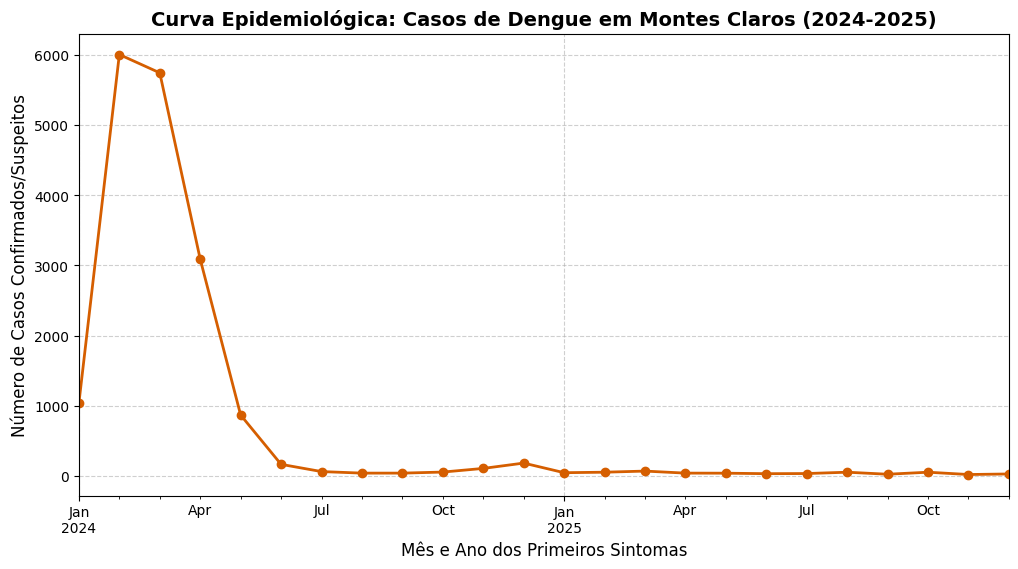

In [ ]:
df_grafico = df_moc[(df_moc['DT_SIN_PRI'].dt.year >= 2024) & (df_moc['DT_SIN_PRI'].dt.year <= 2025)].copy()

df_grafico['ANO_MES'] = df_grafico['DT_SIN_PRI'].dt.to_period('M')

# ordenação
casos_por_mes = df_grafico['ANO_MES'].value_counts().sort_index()

plt.figure(figsize=(12, 6))

# bolinhas nos meses
casos_por_mes.plot(kind='line', marker='o', color='#D55E00', linewidth=2)


plt.title('Curva Epidemiológica: Casos de Dengue em Montes Claros (2024-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mês e Ano dos Primeiros Sintomas', fontsize=12)
plt.ylabel('Número de Casos Confirmados/Suspeitos', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Casos confirmados/suspeitos em 2024: 17408
Casos confirmados/suspeitos em 2025: 503



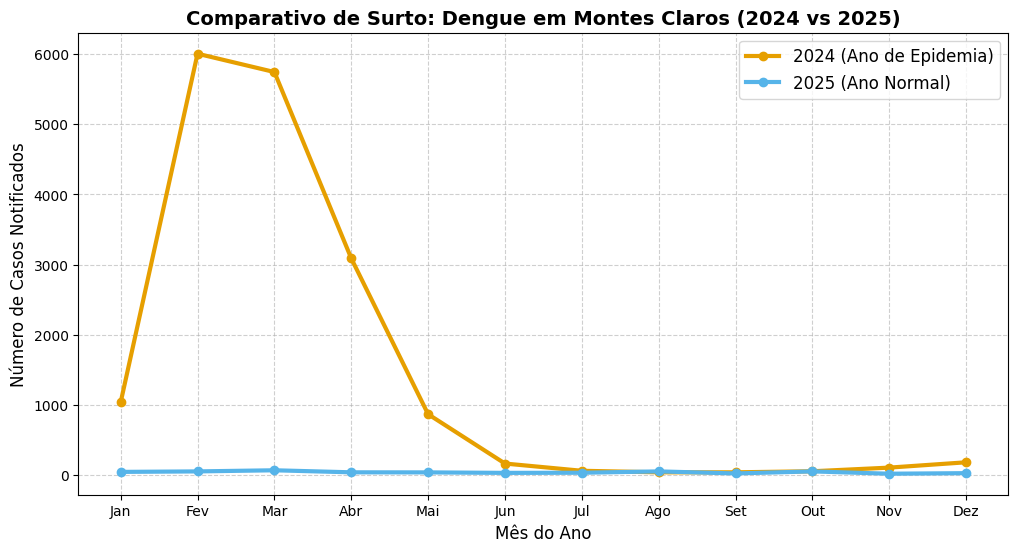

In [ ]:
df_2024 = df_moc[df_moc['DT_SIN_PRI'].dt.year == 2024].copy()
df_2025 = df_moc[df_moc['DT_SIN_PRI'].dt.year == 2025].copy()

print(f"Casos confirmados/suspeitos em 2024: {len(df_2024)}")
print(f"Casos confirmados/suspeitos em 2025: {len(df_2025)}\n")

# conta os casos e agrupa
casos_2024 = df_2024['DT_SIN_PRI'].dt.month.value_counts().sort_index()
casos_2025 = df_2025['DT_SIN_PRI'].dt.month.value_counts().sort_index()

# tamanho do gráfico
plt.figure(figsize=(12, 6))

casos_2024.plot(kind='line', marker='o', color='#E69F00', linewidth=3, label='2024 (Ano de Epidemia)')

casos_2025.plot(kind='line', marker='o', color='#56B4E9', linewidth=3, label='2025 (Ano Normal)')

plt.title('Comparativo de Surto: Dengue em Montes Claros (2024 vs 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Número de Casos Notificados', fontsize=12)

# eixo de baixo
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# legenda
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Insight: Sazonalidade
**2024 (Ano de Surto):**
- Pico de contágio exponencial concentrado nos primeiros meses do ano (fevereiro a abril).
- Curva com elevação drástica, rompendo a média histórica da cidade.

**2025 (Ano de Controle):**
- Curva achatada, com volume de casos drasticamente menor em relação ao ano anterior.
- Doença com comportamento linear de contágio.

**Conclusão:** Existe um contrate ao comparar os casos de 2024 e 2025, evidenciando uma epidemia de dengue em 2024, provavelmente causada pelos volumes fortes de chuva nos meses de Janeiro e Fevereiro. O cenario de 2025 já sugere certa instabilidade da doença, evidenciando comportamento comum da população após um surto de contágio, onde medidas de prevenção e cuidados referentes a doença foram aplicados.

###**Perfil Demográfico**

In [ ]:
df['CS_SEXO'].value_counts()

,count
CS_SEXO,
F,1005798
M,811597
I,3769
,1


In [ ]:
df_moc["CS_SEXO"].value_counts()

,count
CS_SEXO,
F,10469
M,7459


In [ ]:
contagem_porcentagem = (df['CS_SEXO'].value_counts(normalize=True) * 100).round(2)
print(contagem_porcentagem.astype(str) + '%') #separa por porcentagem (minas gerais)

CS_SEXO
F    55.23%
M    44.56%
I     0.21%
       0.0%
Name: proportion, dtype: object


In [ ]:
contagem_porcentagem = (df_moc['CS_SEXO'].value_counts(normalize=True) * 100).round(2)
print(contagem_porcentagem.astype(str) + '%') #porcentagem (montes claros)

CS_SEXO
F    58.39%
M    41.61%
Name: proportion, dtype: object


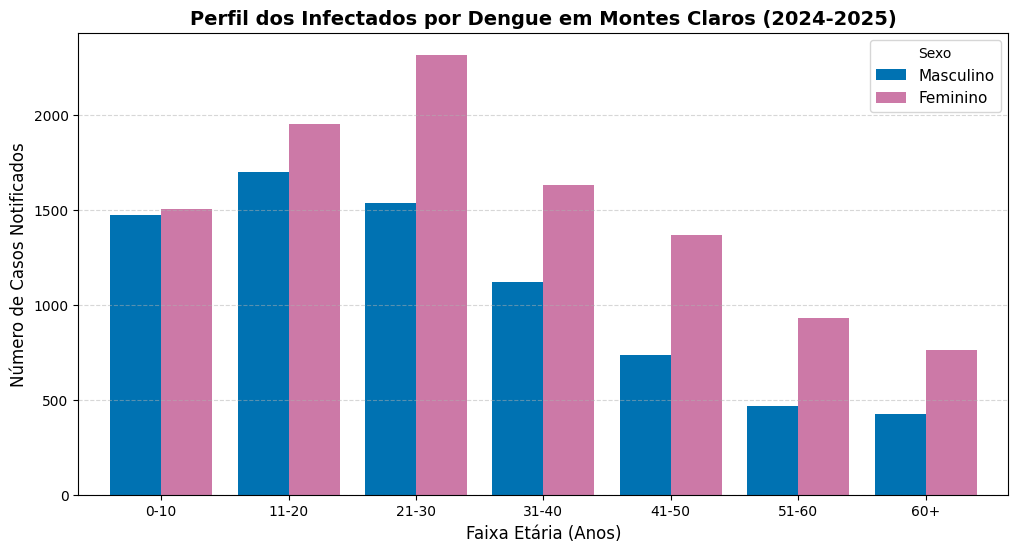

In [ ]:
# cortes de dados
cortes = [-1, 10, 20, 30, 40, 50, 60, 150] # Começa no -1 para garantir que bebês de 0 anos entrem
nomes_faixas = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+']

# separar as idades
df_moc['FAIXA_ETARIA'] = pd.cut(df_moc['NU_IDADE_N'], bins=cortes, labels=nomes_faixas)

tabela_perfil = pd.crosstab(df_moc['FAIXA_ETARIA'], df_moc['CS_SEXO'])

# ignorar casos não preenchidos
colunas_sexo = [col for col in ['M', 'F'] if col in tabela_perfil.columns]
tabela_perfil = tabela_perfil[colunas_sexo]

tabela_perfil.plot(kind='bar', figsize=(12, 6), color=['#0072B2', '#CC79A7'], width=0.8)

plt.title('Perfil dos Infectados por Dengue em Montes Claros (2024-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Faixa Etária (Anos)', fontsize=12)
plt.ylabel('Número de Casos Notificados', fontsize=12)

plt.legend(['Masculino', 'Feminino'], title='Sexo', fontsize=11)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Insight: Perfil Demográfico
**Faixa Etária:**
- Concentração expressiva de notificações na população economicamente ativa (adultos entre 20 e 50 anos).
- Menor incidência em um dos extremos demográficos (idosos).
- Extremo de crianças e adolescente (0 a 20 anos) apesentam concentração preocupante.

**Sexo Biológico:**
- Volume de casos apresenta prevalência moderada no sexo feminino.

**Conclusão:** A doença afeta majoritariamente adultos, com ligeiro predomínio nas mulheres. Isso pode indicar uma maior exposição ao vetor em ambientes residenciais, onde a concentração feminina pode ser maior, ou uma tendência comportamental feminina de buscar atendimento médico mais rápido aos primeiros sintomas. Vale ressaltar que ao se tratar de crianças (0 a 10 anos), nota-se ceta igualdade entre os sexos, e ao comparar com a prevalência feminina nas demais idades. Isso pode indicar um comportamento de cuidado para com as crianças, cuidado esse advindo de seus responsáveis, diminuindo a diferença entre os gêneros (barreira cultural), e refletindo que a taxa de infecção pode ser igualitária.   

-> Média GERAL de Minas Gerais: 3.14 dias
-> Média das MULHERES (MG): 3.23 dias
-> Média dos HOMENS (MG): 3.03 dias



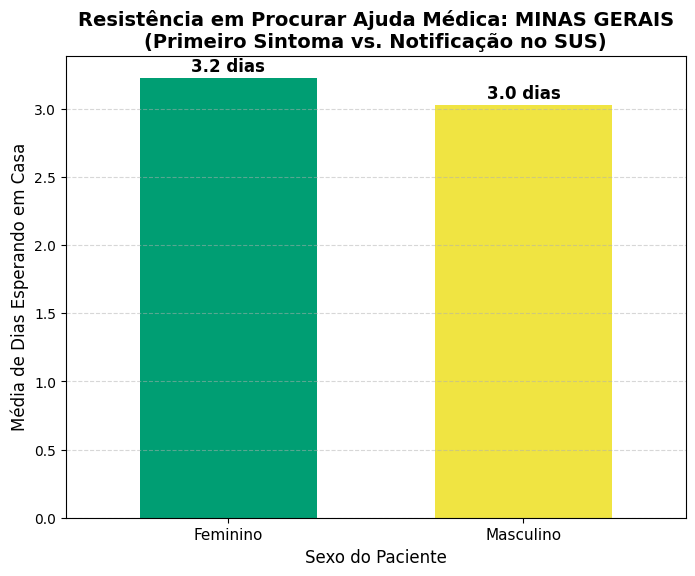

In [ ]:
df['DIAS_ATRASO'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days

df_mg_comportamento = df[(df['DIAS_ATRASO'] >= 0) & (df['DIAS_ATRASO'] <= 30)].copy()

# Agrupa por sexo e tira a média de dias
media_atraso_mg = df_mg_comportamento.groupby('CS_SEXO')['DIAS_ATRASO'].mean()


print(f"-> Média GERAL de Minas Gerais: {df_mg_comportamento['DIAS_ATRASO'].mean():.2f} dias")
print(f"-> Média das MULHERES (MG): {media_atraso_mg['F']:.2f} dias")
print(f"-> Média dos HOMENS (MG): {media_atraso_mg['M']:.2f} dias\n")

plt.figure(figsize=(8, 6))

# Usando Verde e Amarelo Okabe-Ito para diferenciar de Montes Claros
cores_mg = ['#009E73', '#F0E442']

media_atraso_mg[['F', 'M']].plot(kind='bar', color=cores_mg, width=0.6)

plt.title('Resistência em Procurar Ajuda Médica: MINAS GERAIS\n(Primeiro Sintoma vs. Notificação no SUS)', fontsize=14, fontweight='bold')
plt.xlabel('Sexo do Paciente', fontsize=12)
plt.ylabel('Média de Dias Esperando em Casa', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'], rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, valor in enumerate(media_atraso_mg[['F', 'M']]):
    plt.text(i, valor + 0.05, f"{valor:.1f} dias", ha='center', fontsize=12, fontweight='bold')

plt.show()

-> Média GERAL da cidade: 2.57 dias
-> Média das MULHERES: 2.63 dias
-> Média dos HOMENS: 2.48 dias



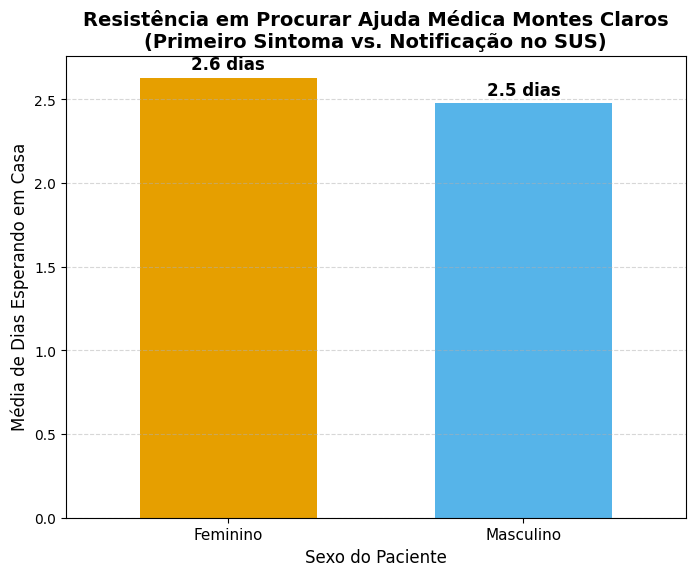

In [ ]:
df_moc['DIAS_ATRASO'] = (df_moc['DT_NOTIFIC'] - df_moc['DT_SIN_PRI']).dt.days

# ignora os erros de digitação
df_comportamento = df_moc[(df_moc['DIAS_ATRASO'] >= 0) & (df_moc['DIAS_ATRASO'] <= 30)].copy()

# agrupa por sexo e tira a média de dias
media_atraso = df_comportamento.groupby('CS_SEXO')['DIAS_ATRASO'].mean()

# descrição
print(f"-> Média GERAL da cidade: {df_comportamento['DIAS_ATRASO'].mean():.2f} dias")
print(f"-> Média das MULHERES: {media_atraso['F']:.2f} dias")
print(f"-> Média dos HOMENS: {media_atraso['M']:.2f} dias\n")

plt.figure(figsize=(8, 6))


cores = ['#E69F00', '#56B4E9']

media_atraso[['F', 'M']].plot(kind='bar', color=cores, width=0.6)

plt.title('Resistência em Procurar Ajuda Médica Montes Claros\n(Primeiro Sintoma vs. Notificação no SUS)', fontsize=14, fontweight='bold')
plt.xlabel('Sexo do Paciente', fontsize=12)
plt.ylabel('Média de Dias Esperando em Casa', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Feminino', 'Masculino'], rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, valor in enumerate(media_atraso[['F', 'M']]):
    plt.text(i, valor + 0.05, f"{valor:.1f} dias", ha='center', fontsize=12, fontweight='bold')

plt.show()

#### Insight: Perfil Demografico: Resistência em Procurar Ajuda Médica por Gênero
**Sexo:**
- Pessoas do sexo biologico feminino apresentam maior resistencia em procurar ajuda médica do que pessoas do sexo masculino. Ainda assim, foi apresentada diferença mínima entre os sexos.

Montes Claros: 0.15 dias de diferença (Feminino - Masculino)

Minas Gerais: 0.2 dias de diferença (Feminino - Masculino)

**Conclusão:** Embora exista uma ligeira demora matemática por parte das mulheres, a diferença se torna clinicamente irrelevante. Na prática, conclui-se que tanto homens quanto mulheres levam o mesmo tempo de resistência antes de procurar ajuda médica.

###**Indicadores de Gravidade**

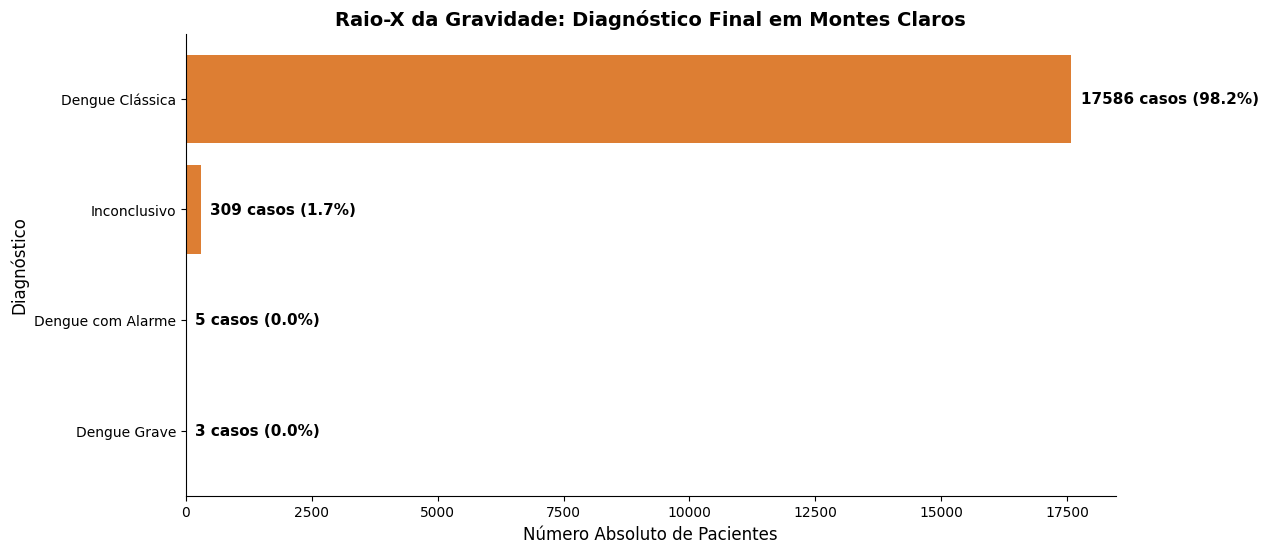

In [ ]:
# conta e ordena do maior pro menor
contagem_diagnostico = df_moc['DIAGNOSTICO'].value_counts(dropna=True).sort_values(ascending=True)
total_casos = contagem_diagnostico.sum()

plt.figure(figsize=(12, 6))

# barras horizontais
barras = plt.barh(contagem_diagnostico.index, contagem_diagnostico.values, color='#D55E00', alpha=0.8)

plt.title('Raio-X da Gravidade: Diagnóstico Final em Montes Claros', fontsize=14, fontweight='bold')
plt.xlabel('Número Absoluto de Pacientes', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# escreve as descrições
for barra in barras:
    largura = barra.get_width() # valor absoluto
    porcentagem = (largura / total_casos) * 100

    # escreve o texto na frente da barra
    plt.text(largura + (total_casos * 0.01),
             barra.get_y() + barra.get_height()/2,
             f"{int(largura)} casos ({porcentagem:.1f}%)",
             va='center', fontsize=11, fontweight='bold')

plt.show()

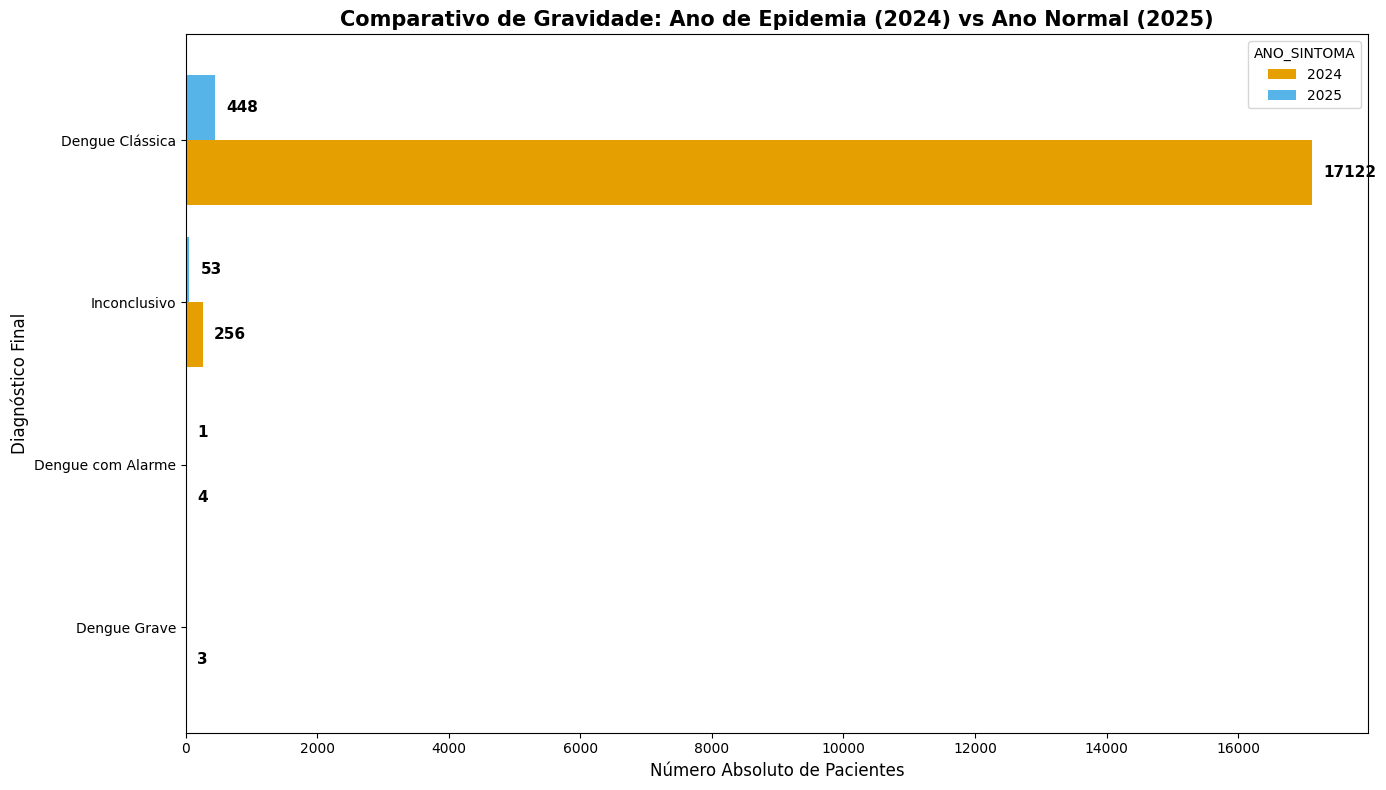

In [ ]:
df_moc['ANO_SINTOMA'] = df_moc['DT_SIN_PRI'].dt.year

tabela_comparativa = pd.crosstab(df_moc['DIAGNOSTICO'], df_moc['ANO_SINTOMA'])

anos_analise = [ano for ano in [2024, 2025] if ano in tabela_comparativa.columns]
tabela_comparativa = tabela_comparativa[anos_analise]

tabela_comparativa['Total'] = tabela_comparativa.sum(axis=1)
tabela_comparativa = tabela_comparativa.sort_values('Total', ascending=True).drop(columns=['Total'])

# pinta o gráfico e monta ele
ax = tabela_comparativa.plot(kind='barh', figsize=(14, 8), color=['#E69F00', '#56B4E9'], width=0.8)

plt.title('Comparativo de Gravidade: Ano de Epidemia (2024) vs Ano Normal (2025)', fontsize=15, fontweight='bold')
plt.xlabel('Número Absoluto de Pacientes', fontsize=12)
plt.ylabel('Diagnóstico Final', fontsize=12)

for p in ax.patches:
    largura = p.get_width()
    if largura > 0:
        ax.text(largura + (tabela_comparativa.max().max() * 0.01), #  X
                p.get_y() + p.get_height() / 2,                  #  Y
                f"{int(largura)}",
                va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight: Evolução Clínica e Gravidade
**Dengue Clássica:**
- Representa a esmagadora maioria dos diagnósticos em ambos os períodos analisados.

**Dengue com Alarme e Dengue Grave:**
- **2024:** Escalada preocupante nos números absolutos de casos graves, pressionando os leitos de UTI do município.
- **2025:** Queda abrupta, com os casos críticos praticamente desaparecendo dos registros.

**Conclusão:** A epidemia de 2024 não foi apenas em volume, mas em letalidade/gravidade. O alívio em 2025 reforça que o município retomou o controle sobre os casos críticos da doença e ainda normalizou a situação de dengue na cidade.

### Considerações Finais
Dentre a análise e pesquisa sobre os casos de dengue, foram identificados padrões como:
- A doença atinge de forma massiva a população economicamente ativa.
- O contágio apresenta uma predominância feminina na fase adulta, mas uma paridade na infância.
- Existe uma resistência temporal semelhante entre homens e mulheres antes de procurar o SUS.
- A gravidade da Dengue é em maioria clássica e em poucos caso evolui para casos alarmantesa.